In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm

DATASET_PATH = "/content/drive/MyDrive/Gastric Cancer/all_image"   # folder with 8 class subfolders
CLEAN_DATASET_PATH = "/content/drive/MyDrive/Gastric Cancer/clean_dataset"

In [2]:
def is_corrupted(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return True
        return False
    except:
        return True

In [3]:
def is_bad_image(img, dark_thresh=40, bright_thresh=220):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_intensity = np.mean(gray)

    if mean_intensity < dark_thresh:
        return "too_dark"
    elif mean_intensity > bright_thresh:
        return "too_bright"
    else:
        return None

In [4]:
os.makedirs(CLEAN_DATASET_PATH, exist_ok=True)

report = {
    "total": 0,
    "corrupted": 0,
    "too_dark": 0,
    "too_bright": 0,
    "kept": 0
}

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    save_class_path = os.path.join(CLEAN_DATASET_PATH, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    for img_name in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
        img_path = os.path.join(class_path, img_name)
        report["total"] += 1

        # Check corruption
        if is_corrupted(img_path):
            report["corrupted"] += 1
            continue

        img = cv2.imread(img_path)

        # Check quality
        status = is_bad_image(img)

        if status == "too_dark":
            report["too_dark"] += 1
            continue

        elif status == "too_bright":
            report["too_bright"] += 1
            continue

        # Save clean image
        save_path = os.path.join(save_class_path, img_name)
        cv2.imwrite(save_path, img)
        report["kept"] += 1

Processing STR: 100%|██████████| 3887/3887 [04:43<00:00, 13.70it/s]


In [5]:
print("\n=== DATA CLEANING REPORT ===")
for k, v in report.items():
    print(f"{k}: {v}")


=== DATA CLEANING REPORT ===
total: 31096
corrupted: 0
too_dark: 8
too_bright: 3394
kept: 27694


In [7]:
REJECTED_PATH = "/content/drive/MyDrive/Gastric Cancer/rejected_samples"
os.makedirs(REJECTED_PATH, exist_ok=True)

In [8]:
if status is not None:
    cv2.imwrite(os.path.join(REJECTED_PATH, img_name), img)

In [1]:
import tensorflow as tf
normalized_dataset = '/content/drive/MyDrive/Gastric Cancer/clean_dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    normalized_dataset,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)



Found 27694 files belonging to 8 classes.
Using 22156 files for training.


In [2]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    normalized_dataset,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 27694 files belonging to 8 classes.
Using 5538 files for validation.


In [3]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

def normalize(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.02, 0.02),
    tf.keras.layers.RandomZoom(0.05),
])

In [5]:
def augment(image, label):
    return data_augmentation(image, training=True), label

train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

In [6]:
#train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
#val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

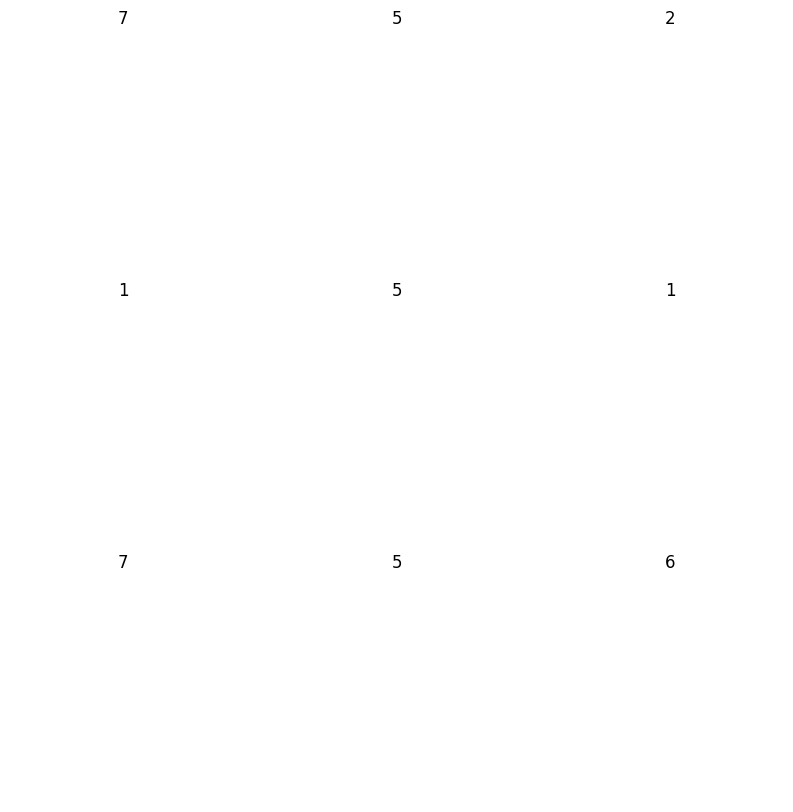

In [6]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow((images[i] + 1)/2)  # reverse preprocess
        plt.title(labels[i].numpy())
        plt.axis("off")
    plt.show()

In [7]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0

NUM_CLASSES = 8
INPUT_SHAPE = (224, 224, 3)

def build_baseline():
    inputs = layers.Input(shape=INPUT_SHAPE)

    # Backbone
    base_model = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    base_model.trainable = False  # Phase 1 (important)

    # Feature extraction
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)

    # Regularization (they used dropout)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Classifier
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model

In [8]:
import tensorflow as tf

model = build_baseline()

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,934,680 (22.64 MB)

 Trainable params: 12,808 (50.03 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Gastric Cancer/best_model.keras',   # where to save
    monitor='val_accuracy',        # metric to track
    mode='max',                   # maximize accuracy
    save_best_only=True,          # only best model
    verbose=1
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks = checkpoint_cb
)

Epoch 1/10
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.2671 - loss: 2.2797
Epoch 1: val_accuracy improved from None to 0.47454, saving model to /content/drive/MyDrive/Gastric Cancer/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Gastric Cancer/best_model.keras
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 1842s 1s/step - accuracy: 0.3380 - loss: 1.9801 - val_accuracy: 0.4745 - val_loss: 1.4297
Epoch 2/10
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.4383 - loss: 1.6038
Epoch 2: val_accuracy improved from 0.47454 to 0.52402, saving model to /content/drive/MyDrive/Gastric Cancer/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Gastric Cancer/best_model.keras
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 417s 300ms/step - accuracy: 0.4471 - loss: 1.5708 - val_accuracy: 0.5240 - val_loss: 1.2982
Epoch 3/10
1384/1385 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4683 - loss: 1.4730
Epoch 3: val_accuracy improved from 0.52402 to 0.54370,

In [14]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/best_model_finetuned.keras")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 9,874,058 (37.67 MB)

 Trainable params: 1,969,688 (7.51 MB)

 Non-trainable params: 3,964,992 (15.13 MB)

 Optimizer params: 3,939,378 (15.03 MB)

In [7]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_layer_1
1 rescaling
2 normalization
3 stem_conv
4 stem_bn
5 stem_activation
6 block1a_project_conv
7 block1a_project_bn
8 block1a_project_activation
9 block2a_expand_conv
10 block2a_expand_bn
11 block2a_expand_activation
12 block2a_project_conv
13 block2a_project_bn
14 block2b_expand_conv
15 block2b_expand_bn
16 block2b_expand_activation
17 block2b_project_conv
18 block2b_project_bn
19 block2b_drop
20 block2b_add
21 block3a_expand_conv
22 block3a_expand_bn
23 block3a_expand_activation
24 block3a_project_conv
25 block3a_project_bn
26 block3b_expand_conv
27 block3b_expand_bn
28 block3b_expand_activation
29 block3b_project_conv
30 block3b_project_bn
31 block3b_drop
32 block3b_add
33 block4a_expand_conv
34 block4a_expand_bn
35 block4a_expand_activation
36 block4a_dwconv2
37 block4a_bn
38 block4a_activation
39 block4a_se_squeeze
40 block4a_se_reshape
41 block4a_se_reduce
42 block4a_se_expand
43 block4a_se_excite
44 block4a_project_conv
45 block4a_project_bn
46 block4b_expand_conv
47

In [8]:
base_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("top_activation").output
)

In [9]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [15]:
trainable = sum([layer.trainable for layer in base_model.layers])
total = len(base_model.layers)

print(f"Trainable layers: {trainable}/{total}")

Trainable layers: 51/270


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,934,680 (22.64 MB)

 Trainable params: 1,969,688 (7.51 MB)

 Non-trainable params: 3,964,992 (15.13 MB)

In [17]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model_finetunedv2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

In [18]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
435/693 ━━━━━━━━━━━━━━━━━━━━ 2:10 504ms/step - accuracy: 0.5782 - loss: 1.1237

KeyboardInterrupt: 

In [46]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.config.optimizer.set_jit(False)   # VERY IMPORTANT

In [47]:
import tensorflow as tf

cnn_model = tf.keras.models.load_model("best_model_finetuned.keras")
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 9,874,058 (37.67 MB)

 Trainable params: 1,969,688 (7.51 MB)

 Non-trainable params: 3,964,992 (15.13 MB)

 Optimizer params: 3,939,378 (15.03 MB)

In [48]:
cnn_backbone = tf.keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("top_activation").output
)

In [49]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0

INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 8

In [50]:
from tensorflow.keras import layers

def transformer_block(x, num_heads=4):
    embed_dim = x.shape[-1]
    key_dim = embed_dim // num_heads

    # 🔥 NO MASK, NO DROPOUT (keep it simple first)
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(x, x, use_causal_mask=False)

    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(embed_dim * 2, activation="relu")(x)
    ffn = layers.Dense(embed_dim)(ffn)

    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization()(x)

    return x

In [51]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import Model

INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 8

def build_hybrid():
    inputs = layers.Input(shape=INPUT_SHAPE)

    base_model = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",   # use imagenet for now (stable)
        input_tensor=inputs
    )

    base_model.trainable = False

    # CNN feature map
    feature_map = base_model.output   # (None, 7, 7, 1280)

    # 🔥 HARD-CODE SAFE SHAPE (VERY IMPORTANT)
    x = layers.Reshape((49, 1280))(feature_map)

    # 🔥 NO embedding for now (avoid shape bugs)
    # (we add later once stable)

    # Transformer
    x = transformer_block(x)
    x = transformer_block(x)

    # Classification
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return Model(inputs, outputs)

In [52]:
model1 = build_hybrid()
model1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,491,864 (123.95 MB)

 Trainable params: 26,572,552 (101.37 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [53]:
import tensorflow as tf
from tensorflow.keras import metrics

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',   # use 'sparse_categorical_crossentropy' if labels are integers
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)

In [54]:
history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node LogicalAnd_1 defined at (most recent call last):
<stack traces unavailable>
Incompatible shapes: [1,32] vs. [1,256]
	 [[{{node LogicalAnd_1}}]]
	tf2xla conversion failed while converting __inference_one_step_on_data_289642[]. Run with TF_DUMP_GRAPH_PREFIX=/path/to/dump/dir and --vmodule=xla_compiler=2 to obtain a dump of the compiled functions.
	 [[StatefulPartitionedCall]] [Op:__inference_multi_step_on_iterator_290639]

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

In [ ]:
tta_augment = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.02, 0.02),
    tf.keras.layers.RandomZoom(0.05),
])

In [ ]:
import numpy as np

def predict_with_tta(model, dataset, tta_steps=5):
    all_preds = []

    for _ in range(tta_steps):
        preds = []

        for images, _ in dataset:
            aug_images = tta_augment(images, training=True)
            pred = model.predict(aug_images, verbose=0)
            preds.append(pred)

        preds = np.concatenate(preds, axis=0)
        all_preds.append(preds)

    # Average predictions
    final_preds = np.mean(all_preds, axis=0)
    return final_preds

In [ ]:
tta_preds = predict_with_tta(model, val_ds, tta_steps=5)
y_pred = np.argmax(tta_preds, axis=1)

In [ ]:
y_true = []

for _, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))